In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pyarrow.parquet as pq
from numba import njit

In [2]:
# Import the datasets
table = pq.read_table('data/training/events.parquet')
events_df = table.to_pandas()
table_truth = pq.read_table('data/training/truth.parquet')
truth_df = table_truth.to_pandas()

# Concatenate the datasets
df = pd.concat([events_df,truth_df], axis = 1)

In [3]:
# Devide the real events and the radio events
neutrino_events = df[ df["pair_id"] != -1 ]
radio_events = df[ df["pair_id"] == -1 ].reset_index(drop=True)

In [4]:
radio_events

,time,energy,x,y,z,label,pair_id,label_name
0,1322603736,1.9035,0.417871,0.744147,-1.359501,3,-1,radio
1,1422647840,1.1535,0.862240,-1.093785,-0.804557,3,-1,radio
2,1568941264,1.2175,-0.763068,1.175093,0.473534,3,-1,radio
3,2439064716,2.7815,-0.832841,-0.665837,0.194716,3,-1,radio
4,3199561416,1.2465,-0.000135,1.316329,-1.528785,3,-1,radio
...,...,...,...,...,...,...,...,...
24843292,12343785134511130,1.5815,-0.536106,1.227229,-1.394481,3,-1,radio
24843293,12343785292632116,1.8425,-0.408005,-1.388106,-1.405729,3,-1,radio
24843294,12343786775083868,2.1575,1.424865,0.364542,0.469062,3,-1,radio
24843295,12343787508531018,2.6255,-1.110649,0.436175,1.395736,3,-1,radio


In [5]:
# Create neutrino pairs with all features
IBDp = neutrino_events[ neutrino_events["label"] == 1 ].sort_values(by='pair_id').reset_index(drop=True)
IBDd = neutrino_events[ neutrino_events["label"] == 2 ].sort_values(by='pair_id').reset_index(drop=True)
R_DET = max(np.sqrt(events_df['x']**2 + events_df['y']**2))
Z_MAX = max(np.abs(events_df['z']))
C = 299792458.0
n_w = 1.33
Vl = C/n_w

# Relativistic features
# ds2 = (C*dt_sec)**2 - dr**2
# beta_eff = dr / (C*dt_sec + eps)

# cherenkov check
# dt_expected = dr / Vl
# time_residual = dt_sec - dt_expected

pairs_dict = { 
    # Single features
    'p_time': IBDp['time'], 
    'Ep': IBDp['energy'],
    # 'p_pair': IBDp['pair_id'],
    'd_time': IBDd['time'],
    'Ed': IBDd['energy'],
    # 'd_pair': IBDd['pair_id'],
    
    # Spatial features
    'delta_x': np.abs(IBDd['x'] - IBDp['x']),
    'delta_y': np.abs(IBDd['y'] - IBDp['y']),
    'delta_z': np.abs(IBDd['z'] - IBDp['z']),
    'zp': IBDp['z'],
    'zd': IBDd['z'],
    'edist': np.sqrt((IBDd['x'] - IBDp['x'])**2 + # euclidean distance
                     (IBDd['y'] - IBDp['y'])**2 +
                     (IBDd['z'] - IBDp['z'])**2),
    'rp': np.sqrt(IBDp['x']**2 + IBDp['y']**2),
    'rd': np.sqrt(IBDd['x']**2 + IBDd['y']**2),
    'dist_wall_p': R_DET - np.sqrt(IBDp['x']**2 + IBDp['y']**2),
    'dist_wall_d': R_DET - np.sqrt(IBDd['x']**2 + IBDd['y']**2),
    'dist_wall_h_p': Z_MAX - np.abs(IBDp['z']),
    'dist_wall_h_d': Z_MAX - np.abs(IBDd['z']),
    'edist_over_r': np.sqrt((IBDd['x'] - IBDp['x'])**2 +  # gli eventi sono vicini o relativamente lontani? rispetto alle dimensioni del detector
                            (IBDd['y'] - IBDp['y'])**2 +
                            (IBDd['z'] - IBDp['z'])**2) /
                            (np.sqrt(IBDp['x']**2 + IBDp['y']**2) + np.sqrt(IBDd['x']**2 + IBDd['y']**2)), # —–> distanza media dal centro o raggio detector
    'theta_p': np.arctan2(IBDp['x'], IBDp['y']),
    'theta_d': np.arctan2(IBDd['x'], IBDd['y']),
    'delta_r': np.abs(np.sqrt(IBDd['x']**2 + IBDd['y']**2) -  # radius absolute difference
                      np.sqrt(IBDp['x']**2 + IBDp['y']**2)),
    'delta_theta': np.arctan2(
                   np.sin(np.arctan2(IBDd['x'], IBDd['y']) - np.arctan2(IBDp['x'], IBDp['y'])),
                   np.cos(np.arctan2(IBDd['x'], IBDd['y']) - np.arctan2(IBDp['x'], IBDp['y']))
                   ),
    
    # Time features
    'delta_t': IBDd['time'] - IBDp['time'],
    'diffusion': ((IBDd['x'] - IBDp['x'])**2 + 
                 (IBDd['y'] - IBDp['y'])**2 +
                 (IBDd['z'] - IBDp['z'])**2) /
                 ((IBDd['time'] - IBDp['time']) +1e-8), # quantità legata alla velocità/media‑quadratica di propagazione delle informazioni di 
                                                # segnale nel volume attivo del rivelatore, oppure alla “diffusione” dei punti rivelati nel tempo.
    
    # Energy features
    'E_sum': IBDd['energy'] + IBDp['energy'],
    'E_diff': np.abs(IBDd['energy'] - IBDp['energy']),
    'E_div': IBDd['energy'] / (IBDp['energy'] +1e-8),
    'E_asym': (IBDd['energy'] - IBDp['energy']) /
              ((IBDd['energy'] + IBDp['energy']) +1e-8), # Energy asymmetry
    
    # Relativistic features
    'ds2': (C*(IBDd['time'] - IBDp['time'])*1e-9)**2 - 
                    ((IBDd['x'] - IBDp['x'])**2 +
                     (IBDd['y'] - IBDp['y'])**2 +
                     (IBDd['z'] - IBDp['z'])**2),
    # 'beta_eff': np.sqrt((IBDd['x'] - IBDp['x'])**2 +
    #              (IBDd['y'] - IBDp['y'])**2 +
    #              (IBDd['z'] - IBDp['z'])**2) /
    #             (C*(IBDd['time'] - IBDp['time'])*1e-9 + 1e-8),

    # Cherenkov check
    # 'time_residual': (IBDd['time'] - IBDp['time'])*1e-9 -
    #                  (np.sqrt((IBDd['x'] - IBDp['x'])**2 +
    #                           (IBDd['y'] - IBDp['y'])**2 +
    #                           (IBDd['z'] - IBDp['z'])**2) / Vl),

    # Target
    'is_event': np.ones(IBDp.shape[0])
}

pairs_ = pd.DataFrame(data=pairs_dict)
pairs = pairs_[ pairs_['delta_t'] <= 2e6 ]


In [6]:
# Create radio pairs - naive method
'''
p_time = []
d_time = []
Ep = []
Ed = []

xp = []
yp = []
zp = []

xd = []
yd = []
zd = []

delta_t = []

N = radio_events.shape[0]

for j in range(N - 1):

    i = 0

    while (j + i + 1) < N:

        dt = radio_events['time'][j + i + 1] - radio_events['time'][j]

        if dt >= 2.5e6:
            break

        delta_t.append(dt)

        p_time.append(radio_events['time'][j])
        Ep.append(radio_events['energy'][j])

        xp.append(radio_events['x'][j])
        yp.append(radio_events['y'][j])
        zp.append(radio_events['z'][j])

        d_time.append(radio_events['time'][j + i + 1])
        Ed.append(radio_events['energy'][j + i + 1])

        xd.append(radio_events['x'][j + i + 1])
        yd.append(radio_events['y'][j + i + 1])
        zd.append(radio_events['z'][j + i + 1])

        i += 1
'''

"\np_time = []\nd_time = []\nEp = []\nEd = []\n\nxp = []\nyp = []\nzp = []\n\nxd = []\nyd = []\nzd = []\n\ndelta_t = []\n\nN = radio_events.shape[0]\n\nfor j in range(N - 1):\n\n    i = 0\n\n    while (j + i + 1) < N:\n\n        dt = radio_events['time'][j + i + 1] - radio_events['time'][j]\n\n        if dt >= 2.5e6:\n            break\n\n        delta_t.append(dt)\n\n        p_time.append(radio_events['time'][j])\n        Ep.append(radio_events['energy'][j])\n\n        xp.append(radio_events['x'][j])\n        yp.append(radio_events['y'][j])\n        zp.append(radio_events['z'][j])\n\n        d_time.append(radio_events['time'][j + i + 1])\n        Ed.append(radio_events['energy'][j + i + 1])\n\n        xd.append(radio_events['x'][j + i + 1])\n        yd.append(radio_events['y'][j + i + 1])\n        zd.append(radio_events['z'][j + i + 1])\n\n        i += 1\n"

In [7]:
# =========================================================
# Conversione pandas -> numpy
# =========================================================

times = radio_events['time'].to_numpy(dtype=np.float64)

energy = radio_events['energy'].to_numpy(dtype=np.float32)

x = radio_events['x'].to_numpy(dtype=np.float32)
y = radio_events['y'].to_numpy(dtype=np.float32)
z = radio_events['z'].to_numpy(dtype=np.float32)

# =========================================================
# Geometria detector
# =========================================================

R_DET = np.max(
    np.sqrt(
        events_df['x']**2 +
        events_df['y']**2
    )
).astype(np.float32)

Z_MAX = np.max(
    np.abs(events_df['z'])
).astype(np.float32)


# =========================================================
# Funzione Numba
# =========================================================

@njit
def build_background_pairs(
    times,
    energy,
    x,
    y,
    z,
    R_DET,
    Z_MAX,
    max_dt=2e6
):

    N = len(times)

    # =====================================================
    # Conta coppie
    # =====================================================

    n_pairs = 0

    for j in range(N - 1):

        k = j + 1

        while k < N:

            dt = times[k] - times[j]

            if dt >= max_dt:
                break

            n_pairs += 1
            k += 1

    # =====================================================
    # Allocazione array
    # =====================================================

    p_time = np.empty(n_pairs, dtype=np.float64)
    d_time = np.empty(n_pairs, dtype=np.float64)

    Ep = np.empty(n_pairs, dtype=np.float32)
    Ed = np.empty(n_pairs, dtype=np.float32)

    delta_x = np.empty(n_pairs, dtype=np.float32)
    delta_y = np.empty(n_pairs, dtype=np.float32)
    delta_z = np.empty(n_pairs, dtype=np.float32)

    edist = np.empty(n_pairs, dtype=np.float32)

    rp = np.empty(n_pairs, dtype=np.float32)
    rd = np.empty(n_pairs, dtype=np.float32)

    zp = np.empty(n_pairs, dtype=np.float32)
    zd = np.empty(n_pairs, dtype=np.float32)

    dist_wall_p = np.empty(n_pairs, dtype=np.float32)
    dist_wall_d = np.empty(n_pairs, dtype=np.float32)

    dist_wall_h_p = np.empty(n_pairs, dtype=np.float32)
    dist_wall_h_d = np.empty(n_pairs, dtype=np.float32)

    edist_over_r = np.empty(n_pairs, dtype=np.float32)

    theta_p = np.empty(n_pairs, dtype=np.float32)
    theta_d = np.empty(n_pairs, dtype=np.float32)

    delta_r = np.empty(n_pairs, dtype=np.float32)

    delta_theta = np.empty(n_pairs, dtype=np.float32)

    delta_t = np.empty(n_pairs, dtype=np.float64)

    diffusion = np.empty(n_pairs, dtype=np.float32)

    E_sum = np.empty(n_pairs, dtype=np.float32)
    E_diff = np.empty(n_pairs, dtype=np.float32)
    E_div = np.empty(n_pairs, dtype=np.float32)

    E_asym = np.empty(n_pairs, dtype=np.float32)

    ds2 = np.empty(n_pairs, dtype=np.float32)
    # beta_eff = np.empty(n_pairs, dtype=np.float64)

    # time_residual = np.empty(n_pairs, dtype=np.float64)

    is_event = np.zeros(n_pairs, dtype=np.int8)

    # =====================================================
    # Riempimento
    # =====================================================

    idx = 0

    for j in range(N - 1):

        k = j + 1

        while k < N:

            dt = times[k] - times[j]

            if dt >= max_dt:
                break

            # -------------------------------------------------
            # Coordinate differences
            # -------------------------------------------------

            dx = np.abs(x[k] - x[j])
            dy = np.abs(y[k] - y[j])
            dz = np.abs(z[k] - z[j])

            z_p = z[j]
            z_d = z[k]

            dist = np.sqrt(
                (x[k] - x[j])**2 +
                (y[k] - y[j])**2 +
                (z[k] - z[j])**2
            )

            # -------------------------------------------------
            # Cylindrical radii
            # -------------------------------------------------

            rp_val = np.sqrt(
                x[j]**2 +
                y[j]**2
            )

            rd_val = np.sqrt(
                x[k]**2 +
                y[k]**2
            )

            # -------------------------------------------------
            # Angles
            # -------------------------------------------------

            theta_p_val = np.arctan2(
                x[j],
                y[j]
            )

            theta_d_val = np.arctan2(
                x[k],
                y[k]
            )

            dtheta = np.arctan2(
                np.sin(theta_d_val - theta_p_val),
                np.cos(theta_d_val - theta_p_val)
            )

            # -------------------------------------------------
            # Fill arrays
            # -------------------------------------------------

            p_time[idx] = times[j]
            d_time[idx] = times[k]

            Ep[idx] = energy[j]
            Ed[idx] = energy[k]

            delta_x[idx] = dx
            delta_y[idx] = dy
            delta_z[idx] = dz

            zp[idx] = z_p
            zd[idx] = z_d

            edist[idx] = dist

            rp[idx] = rp_val
            rd[idx] = rd_val

            dist_wall_p[idx] = R_DET - rp_val
            dist_wall_d[idx] = R_DET - rd_val

            dist_wall_h_p[idx] = (
                Z_MAX - np.abs(z[j])
            )

            dist_wall_h_d[idx] = (
                Z_MAX - np.abs(z[k])
            )

            edist_over_r[idx] = (
                dist / (rp_val + rd_val)
            )

            theta_p[idx] = theta_p_val
            theta_d[idx] = theta_d_val

            delta_r[idx] = np.abs(
                rd_val - rp_val
            )

            delta_theta[idx] = dtheta

            delta_t[idx] = dt

            diffusion[idx] = (dist**2) / (dt +1e-8)

            E_sum[idx] = (
                energy[k] + energy[j]
            )

            E_diff[idx] = np.abs(
                energy[k] - energy[j]
            )

            E_div[idx] = (
                energy[k] / energy[j]
            )

            E_asym[idx] = (
                (energy[k] - energy[j]) /
                (energy[k] + energy[j])
            )

            ds2[idx] = (C*dt*1e-9)**2 - dist**2

            # beta_eff[idx] = dist / (C*dt*1e-9 +1e-8)

            # time_residual[idx] = dt*1e-9 - (dist / Vl)

            idx += 1
            k += 1

    return (
        p_time,
        Ep,

        d_time,
        Ed,

        delta_x,
        delta_y,
        delta_z,

        zp,
        zd,

        edist,

        rp,
        rd,

        dist_wall_p,
        dist_wall_d,

        dist_wall_h_p,
        dist_wall_h_d,

        edist_over_r,

        theta_p,
        theta_d,

        delta_r,

        delta_theta,

        delta_t,

        diffusion,

        E_sum,
        E_diff,
        E_div,

        E_asym,

        ds2,
        # beta_eff,

        # time_residual,

        is_event
    )


# =========================================================
# Esecuzione
# =========================================================

(
    p_time,
    Ep,

    d_time,
    Ed,

    delta_x,
    delta_y,
    delta_z,

    zp,
    zd,

    edist,

    rp,
    rd,

    dist_wall_p,
    dist_wall_d,

    dist_wall_h_p,
    dist_wall_h_d,

    edist_over_r,

    theta_p,
    theta_d,

    delta_r,

    delta_theta,

    delta_t,

    diffusion,

    E_sum,
    E_diff,
    E_div,

    E_asym,

    ds2,
    # beta_eff,

    # time_residual,

    is_event

) = build_background_pairs(
    times,
    energy,
    x,
    y,
    z,
    R_DET,
    Z_MAX,
    max_dt=2e6
)


# =========================================================
# Dizionario finale
# =========================================================

radio_dict = {

    # Single features
    'p_time': p_time,
    'Ep': Ep,

    'd_time': d_time,
    'Ed': Ed,

    # Spatial features
    'delta_x': delta_x,
    'delta_y': delta_y,
    'delta_z': delta_z,

    'zp': zp,
    'zd': zd,

    'edist': edist,

    'rp': rp,
    'rd': rd,

    'dist_wall_p': dist_wall_p,
    'dist_wall_d': dist_wall_d,

    'dist_wall_h_p': dist_wall_h_p,
    'dist_wall_h_d': dist_wall_h_d,

    'edist_over_r': edist_over_r,

    'theta_p': theta_p,
    'theta_d': theta_d,

    'delta_r': delta_r,

    'delta_theta': delta_theta,

    # Time features
    'delta_t': delta_t,

    'diffusion': diffusion,

    # Energy features
    'E_sum': E_sum,
    'E_diff': E_diff,
    'E_div': E_div,

    'E_asym': E_asym,

    # Relativistic features
    'ds2': ds2,
    # 'beta_eff': beta_eff,

    # Cherenkov feature
    # 'time_residual': time_residual,

    # Labels
    'is_event': is_event
}


# =========================================================
# DataFrame finale
# =========================================================

radio = pd.DataFrame(radio_dict)

print(radio.shape)

radio.head()

(99945, 29)


,p_time,Ep,d_time,Ed,delta_x,delta_y,delta_z,zp,zd,edist,...,delta_r,delta_theta,delta_t,diffusion,E_sum,E_diff,E_div,E_asym,ds2,is_event
0,2.463830e+11,2.3915,2.463844e+11,2.4745,1.298537,0.456462,2.581709,1.035193,-1.546516,2.925710,...,0.312748,1.182435,1369491.0,0.000006,4.866,0.083,1.034706,0.017057,1.685620e+11,0
1,3.030906e+11,2.4595,3.030923e+11,0.8275,0.493390,0.136451,1.192010,1.532031,0.340020,1.297282,...,0.130455,-0.368762,1649948.0,0.000001,3.287,1.632,0.336450,-0.496501,2.446707e+11,0
2,6.159235e+11,2.5615,6.159242e+11,0.8645,0.207884,0.212847,1.291113,1.091380,-0.199734,1.324950,...,0.188215,-0.164789,712102.0,0.000002,3.426,1.697,0.337498,-0.495330,4.557491e+10,0
3,1.042205e+12,0.9785,1.042206e+12,2.5845,0.990710,0.850250,0.165889,-1.274637,-1.440526,1.316036,...,0.396625,1.122170,1080592.0,0.000002,3.563,1.606,2.641288,0.450744,1.049458e+11,0
4,1.085327e+12,0.9915,1.085328e+12,2.2475,2.339687,0.552017,0.573776,1.112369,0.538593,2.471453,...,0.075421,-1.961647,1826371.0,0.000003,3.239,1.256,2.266768,0.387774,2.997916e+11,0


In [8]:
radio.info()

<class 'pandas.DataFrame'>
RangeIndex: 99945 entries, 0 to 99944
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   p_time         99945 non-null  float64
 1   Ep             99945 non-null  float32
 2   d_time         99945 non-null  float64
 3   Ed             99945 non-null  float32
 4   delta_x        99945 non-null  float32
 5   delta_y        99945 non-null  float32
 6   delta_z        99945 non-null  float32
 7   zp             99945 non-null  float32
 8   zd             99945 non-null  float32
 9   edist          99945 non-null  float32
 10  rp             99945 non-null  float32
 11  rd             99945 non-null  float32
 12  dist_wall_p    99945 non-null  float32
 13  dist_wall_d    99945 non-null  float32
 14  dist_wall_h_p  99945 non-null  float32
 15  dist_wall_h_d  99945 non-null  float32
 16  edist_over_r   99945 non-null  float32
 17  theta_p        99945 non-null  float32
 18  theta_d        99

In [9]:
pairs.to_parquet("events.parquet")
radio.to_parquet("background.parquet")

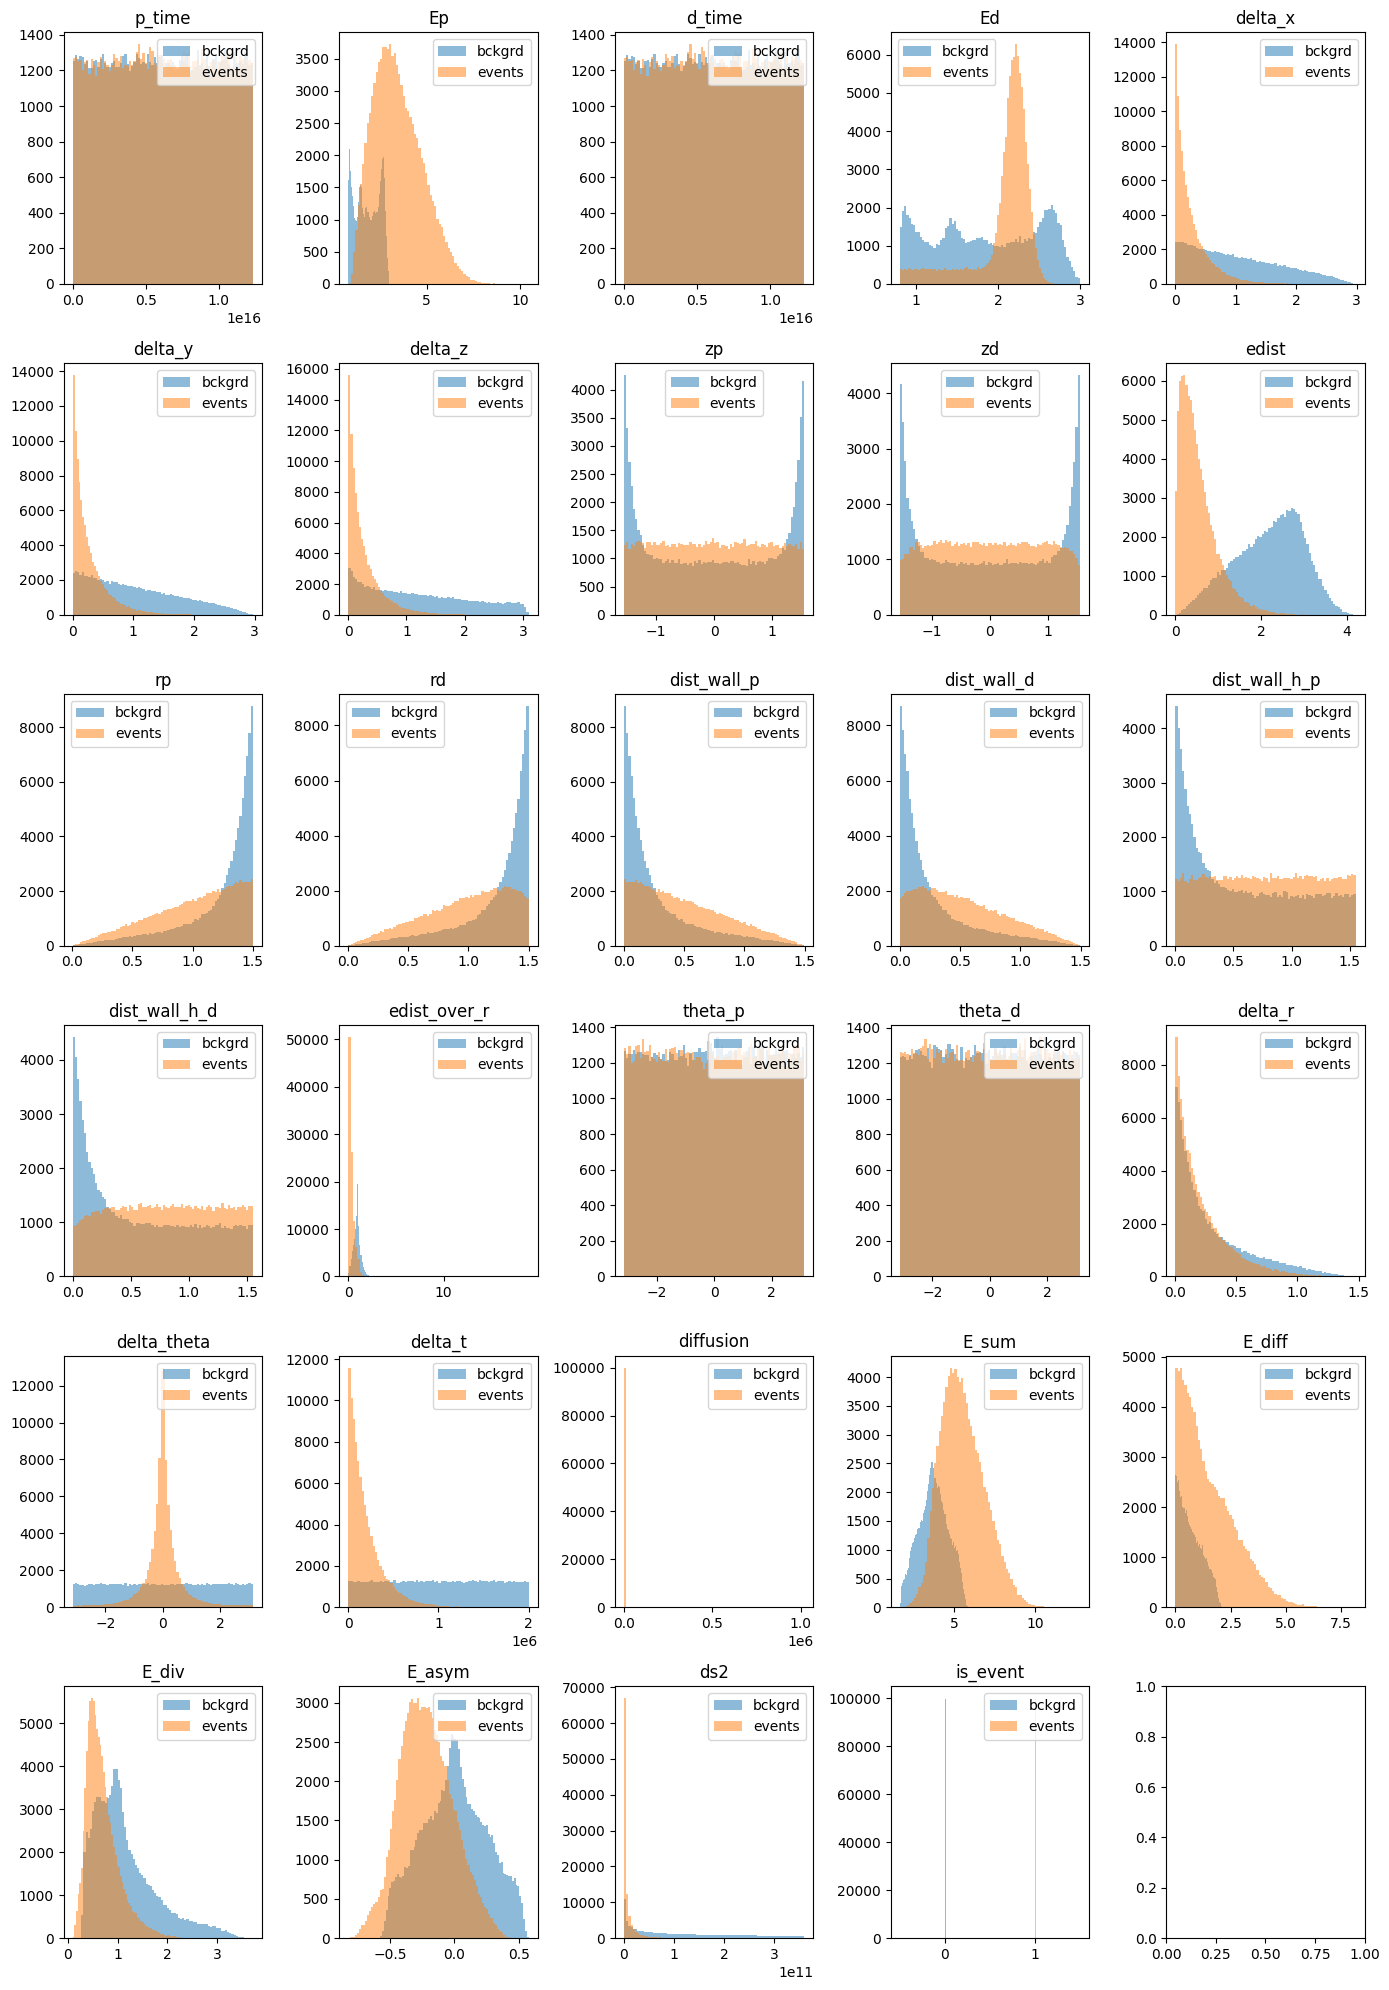

In [10]:
# ax = []
j = 0
fig, ax = plt.subplots(6,5, figsize=(14,20))
ax = ax.flatten()

for i, key in enumerate(radio):
    if i >= ax.size:
        break

    ax[i].hist(radio[key], bins=80, alpha=0.5, label='bckgrd')
    ax[i].hist(pairs[key], bins=80, alpha=0.5, label='events')
    ax[i].set_title(key)
    ax[i].legend()

plt.tight_layout()
plt.show()


In [11]:
config = {
    'delta_x': {'tr': np.sqrt, 'label': 'sqrt_delta_x'},
    'delta_y': {'tr': np.sqrt, 'label': 'sqrt_delta_y'},
    'delta_z': {'tr': np.sqrt, 'label': 'sqrt_delta_z'},
    'edist': {'tr': np.sqrt, 'label': 'sqrt_edist'},
    'edist_over_r': {'tr': np.log10, 'label': 'sqrt_edist_over_r'}, # -> to change R with rp+rd
    'dist_wall_p': {'tr': np.sqrt, 'label': 'sqrt_dist_wall_p'},
    'dist_wall_d': {'tr': np.sqrt, 'label': 'sqrt_dist_wall_d'},
    'dist_wall_h_p': {'tr': np.sqrt, 'label': 'sqrt_dist_wall_h_p'},
    'dist_wall_h_d': {'tr': np.sqrt, 'label': 'sqrt_dist_wall_h_d'},
    'delta_r': {'tr': np.sqrt, 'label': 'sqrt_delta_r'},
    'delta_t': {'tr': np.sqrt, 'label': 'sqrt_delta_t'},
    'diffusion': {'tr': np.log10, 'label': 'log10(diffusion)'},
    # 'rp':     {'tr': lambda x: np.log10(1/np.sin(x)), 'label': '1/rp'},
    # 'rd':     {'tr': lambda x: np.sqrt(1/(x+1)), 'label': '1/rd'},
    'E_diff': {'tr': np.sqrt, 'label': 'sqrt_E_diff'},
    'E_div': {'tr': np.log, 'label': 'log(E_div)'},
    'ds2': {'tr': lambda x: np.log10(x+5), 'label': 'log10(ds2)'},
    # 'beta_eff': {'tr': np.log10, 'label': 'log10(beta_eff)'},
    # 'time_residual': {'tr': np.sqrt, 'label': 'sqrt_time_res'}
}

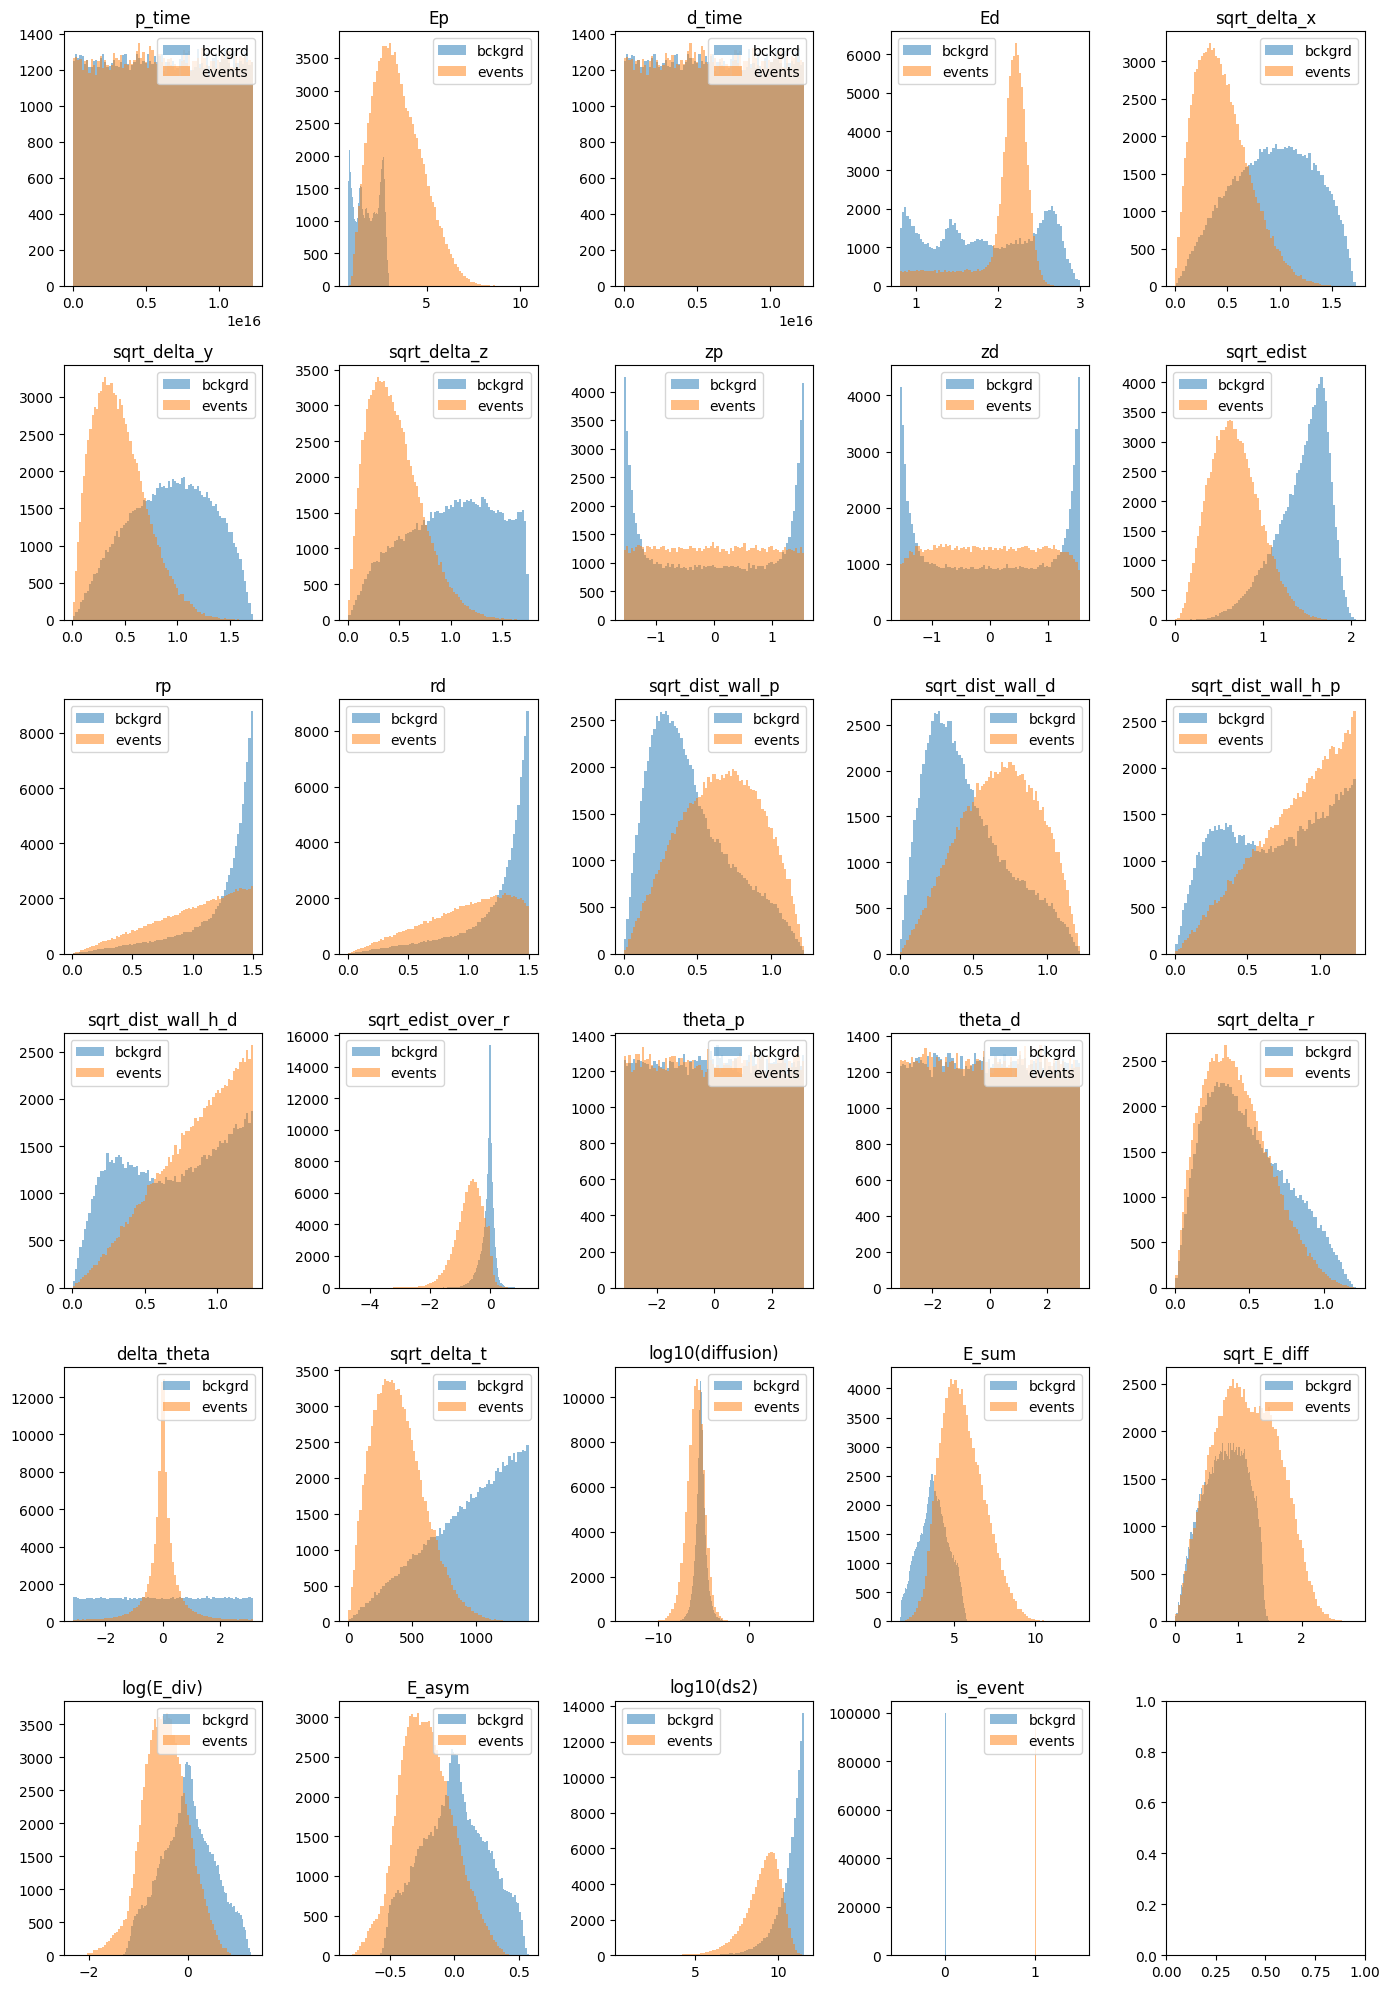

In [12]:
fig, axs = plt.subplots(6,5, figsize=(14,20))
axs = axs.flatten()

for i, key in enumerate(radio):
    if i >= 29:
        break

    ax = axs[i]
    entry = config.get(key, {'tr': lambda x: x, 'label': key})

    ax.hist(entry['tr'](radio[key]), bins=80, alpha=0.5, label='bckgrd')
    ax.hist(entry['tr'](pairs[key]), bins=80, alpha=0.5, label='events')
    ax.set_title(entry['label'])
    ax.legend()

plt.tight_layout()
plt.show()

Looking at the graphs we can drop the following features: \
p_time\
d_time\
—> Ep: important not to bias the spectrum\
theta_p\
theta_d\
E_diff\
E_div

In [13]:
def build_transformed_df(df, config):
    df_tr = df.copy()
    for col in df.columns:
        entry = config.get(col, {'tr': lambda x: x})
        df_tr[col] = entry['tr'](df[col])
    return df_tr

In [14]:
radio_df_tr = build_transformed_df(radio, config)
pairs_df_tr = build_transformed_df(pairs, config)

In [16]:
pairs_df_tr.to_parquet("events_tr.parquet")
radio_df_tr.to_parquet("background_tr.parquet")

# PCA analysis

In [17]:
df_combined = pd.concat([radio_df_tr, pairs_df_tr], ignore_index=True) # Concatenate the dataframes
data = df_combined.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle the samples
X = data.drop(columns=["is_event"]) # Drop the target feature

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

pca = PCA(n_components=0.98) # keep 98% variance
X_reduced = pca.fit_transform(Xs)

In [19]:
components = pca.components_.T  # columns are principal axes in original feature space
explained_variance_ratio = pca.explained_variance_ratio_

print("Reduced shape:", X_reduced.shape)
print("Explained variance ratio:", explained_variance_ratio)

Reduced shape: (199941, 18)
Explained variance ratio: [0.24142534 0.10466852 0.09127865 0.07142985 0.06259717 0.05018465
 0.04886391 0.04767031 0.04700283 0.04039073 0.03571553 0.02376098
 0.02368043 0.02255772 0.02118578 0.0197743  0.01918979 0.0163412 ]


In [20]:
importance = np.sum(np.abs(components.T) * explained_variance_ratio[:, None], axis=0)
feature_names = X.columns
feature_importance = pd.Series(importance, index=feature_names).sort_values(ascending=False)

print(feature_importance)

edist_over_r     0.138552
E_sum            0.138543
diffusion        0.136181
dist_wall_p      0.136139
rp               0.134551
dist_wall_d      0.133230
E_asym           0.133110
E_div            0.132908
rd               0.131518
Ep               0.129396
delta_z          0.129242
edist            0.127838
delta_y          0.127659
delta_x          0.126986
delta_t          0.126047
ds2              0.125502
E_diff           0.125118
Ed               0.124156
dist_wall_h_d    0.118052
dist_wall_h_p    0.113818
delta_r          0.108603
zd               0.064005
zp               0.063884
theta_p          0.061959
theta_d          0.061067
p_time           0.053059
d_time           0.053059
delta_theta      0.038637
dtype: float64


The PCA analysis confirms that the selected variables are of low importance. We try a new analysis after dropping them. We also drop Ep for the reasons specified before.

In [21]:
X_dropped = data.drop(columns=['is_event', 'p_time', 'd_time', 'E_diff', 'E_div', 'theta_p', 'theta_d', 'Ep'])
scaler_ = StandardScaler()
Xs_ = scaler.fit_transform(X_dropped)
pca_ = PCA(n_components=0.98) # keep 98% variance
X_reduced_ = pca_.fit_transform(Xs_)
components_ = pca_.components_.T  # columns are principal axes in original feature space
explained_variance_ratio_ = pca_.explained_variance_ratio_
print("Reduced shape:", X_reduced_.shape)
print("Explained variance ratio:", explained_variance_ratio_)

Reduced shape: (199941, 14)
Explained variance ratio: [0.2740988  0.13902937 0.08405971 0.07062785 0.06513915 0.06282123
 0.05413869 0.04762566 0.04486395 0.03153666 0.03010541 0.02824803
 0.02635063 0.02544534]


In [22]:
importance_ = np.sum(np.abs(components_.T) * explained_variance_ratio_[:, None], axis=0)
feature_names_ = X_dropped.columns
feature_importance_ = pd.Series(importance_, index=feature_names_).sort_values(ascending=False)

print(feature_importance_)

dist_wall_p      0.169892
rp               0.169357
dist_wall_d      0.166898
rd               0.165734
edist_over_r     0.158767
dist_wall_h_d    0.157955
dist_wall_h_p    0.154668
ds2              0.153752
diffusion        0.153071
delta_t          0.152629
E_asym           0.151532
delta_z          0.149594
delta_y          0.149279
delta_x          0.148800
E_sum            0.144587
edist            0.144264
delta_r          0.131770
Ed               0.128050
zd               0.074010
zp               0.073921
delta_theta      0.051730
dtype: float64


We can do a final cut of the last 6/7 features to see what happens

In [23]:
X_dropped = data.drop(columns=['is_event', 'p_time', 'd_time', 'E_diff', 'E_div', 'theta_p', 'theta_d', 'Ep', 'delta_theta','zp','zd','Ed','delta_r', 'edist'])
scaler_ = StandardScaler()
Xs_ = scaler.fit_transform(X_dropped)
pca_ = PCA(n_components=0.98) # keep 98% variance
X_reduced_ = pca_.fit_transform(Xs_)
components_ = pca_.components_.T  # columns are principal axes in original feature space
explained_variance_ratio_ = pca_.explained_variance_ratio_
print("Reduced shape:", X_reduced_.shape)
print("Explained variance ratio:", explained_variance_ratio_)

Reduced shape: (199941, 10)
Explained variance ratio: [0.32051641 0.16860147 0.11608562 0.08815184 0.07820072 0.06732576
 0.03956235 0.0375288  0.03641971 0.02882889]


In [24]:
importance_ = np.sum(np.abs(components_.T) * explained_variance_ratio_[:, None], axis=0)
feature_names_ = X_dropped.columns
feature_importance_ = pd.Series(importance_, index=feature_names_).sort_values(ascending=False)

print(feature_importance_)

dist_wall_p      0.214089
rp               0.213754
rd               0.210900
dist_wall_d      0.210457
edist_over_r     0.206002
delta_x          0.198472
delta_y          0.198348
ds2              0.195262
delta_t          0.191467
diffusion        0.190152
delta_z          0.189733
dist_wall_h_d    0.186507
dist_wall_h_p    0.181900
E_sum            0.179400
E_asym           0.178125
dtype: float64


## Save final datasets

In [25]:
pca_pairs_df_tr = pairs_df_tr.drop(columns=['p_time', 'd_time', 'E_diff', 'E_div', 'theta_p', 'theta_d', 'Ep', 'delta_theta','zp','zd','Ed','delta_r', 'edist'])
pca_radio_df_tr = radio_df_tr.drop(columns=['p_time', 'd_time', 'E_diff', 'E_div', 'theta_p', 'theta_d', 'Ep', 'delta_theta','zp','zd','Ed','delta_r', 'edist'])

In [26]:
pca_pairs_df_tr.to_parquet("preproc_data/pca_events_tr.parquet")
pca_radio_df_tr.to_parquet("preproc_data/pca_background_tr.parquet")